# <font color="blue">Пространственное распределение региональных статистических данных по территории субъекта РФ на сетке 1×1 км</font> 
---

Установка необходимых библиотек (запустить один раз)

In [1]:
#!pip install quackosm
#!pip install geopandas pyogrio

Импорт библиотек

In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, Point
import pandas as pd
import numpy as np
import json
from matplotlib.colors import LogNorm
from map_parsing import *
from scipy.spatial import cKDTree
from scipy.sparse import csr_matrix

import warnings

warnings.filterwarnings("ignore")

%load_ext jupyter_black

### <font color="green">Загрузка данных, создание сетки и сохранение результатов</font> 

In [3]:
name = input("Введите samara_oblast или jewish_autonomous_oblast: ")

if name not in ["samara_oblast", "jewish_autonomous_oblast"]:
    raise ValueError(
        f"Некорректный ввод: '{name}'. Допустимые значения: samara_oblast, jewish_autonomous_oblast"
    )

path_geojson = f"sources/{name}.geojson"
path_pbf = f"sources/{name}.pbf"

print(f"\n✅ Выбран субъект: {name}")
print(f"Граница: {path_geojson}")
print(f"OSM: {path_pbf}")

Введите samara_oblast или jewish_autonomous_oblast:  samara_oblast



✅ Выбран субъект: samara_oblast
Граница: sources/samara_oblast.geojson
OSM: sources/samara_oblast.pbf


In [4]:
# Загружаем границу и все слои OSM
boundary, layers, all_layers = read_map(path_geojson, path_pbf)

Можно вывести информацио о загруженных слоях
```python
print("\nДоступные слои:", list(all_layers.keys()))
print(f"Точек: {len(all_layers.get('points', [])):,}")
print(f"Линий: {len(all_layers.get('lines', [])):,}")
print(f"Полигонов: {len(all_layers.get('multipolygons', [])):,}")

In [5]:
# Создаём сетку ячеек 1×1 км внутри границы
grid_gdf, cell_w, cell_h = create_grid_within_boundary(boundary, cell_size_km=1)

# Агрегируем все слои OSM в сетку (подсчитываем объекты по ячейкам)
final_stats = aggregate_all_layers_to_grid(all_layers, grid_gdf, boundary)

# Создаём текстовые описания для каждой ячейки
descriptions = final_stats.apply(
    lambda row: create_cell_description(row, all_layers), axis=1
)
final_stats["types_json"] = descriptions.apply(lambda x: x[1])  # JSON

# Добавляем координаты центров ячеек (для визуализации)
if "geometry" in final_stats.columns:
    final_stats["center_lon"] = final_stats["geometry"].apply(
        lambda geom: geom.centroid.x
    )
    final_stats["center_lat"] = final_stats["geometry"].apply(
        lambda geom: geom.centroid.y
    )

# Считаем общее количество объектов в каждой ячейке (сумма по всем слоям)
count_cols = [f"count_{layer}" for layer in all_layers.keys()]
final_stats["total_objects"] = final_stats[count_cols].sum(axis=1)

Размер ячейки: 1 км
Сетка в bounding box: 311 × 327 = 101697 ячеек
Ячеек внутри границы: 57034

Итоговая таблица: 57034 ячеек
Колонки: ['cell_id', 'count_points', 'types_points', 'count_lines', 'types_lines', 'count_multilinestrings', 'types_multilinestrings', 'count_multipolygons', 'types_multipolygons', 'count_other_relations', 'types_other_relations', 'cell_x', 'cell_y', 'geometry']


### <font color="green">Извлечение информации для ячеек</font> 

In [6]:
# DataFrame для работы
df_main = final_stats.drop(columns=["geometry"]).copy()
df_main["types_json"] = df_main["types_json"].apply(safe_json_parse)

In [7]:
def extract_buildings_count(types_json):
    """
    Извлекает количество зданий из JSON-описания ячейки.
    Ищет все объекты, в названии типа которых есть "building".
    """
    if isinstance(types_json, dict):
        total = 0
        for layer_data in types_json.get("layers", {}).values():
            for obj_type, count in layer_data.get("types", {}).items():
                if "building" in obj_type:
                    total += count
        return total
    return 0


def extract_total_objects(types_json):
    """
    Извлекает общее количество всех объектов из JSON-описания ячейки.
    Суммирует все типы объектов без фильтрации.
    """
    if isinstance(types_json, dict):
        total = 0
        for layer_data in types_json.get("layers", {}).values():
            total += sum(layer_data.get("types", {}).values())
        return total
    return 0

In [8]:
# Добавляем в df_main колонки с количеством зданий и общим количеством объектов
df_main["total_buildings"] = df_main["types_json"].apply(extract_buildings_count)
df_main["total_objects"] = df_main["types_json"].apply(extract_total_objects)

In [9]:
# Выводим статистику
print(f"✅ Загружено: {len(df_main)} ячеек")
print(f"  Ячеек с зданиями: {(df_main['total_buildings'] > 0).sum():,}")
print(f"  Всего зданий: {df_main['total_buildings'].sum():,}")

✅ Загружено: 57034 ячеек
  Ячеек с зданиями: 7,645
  Всего зданий: 485,186


### <font color="green">Частотный анализ с весами (редкие объекты = больший вес)</font> 

In [10]:
# Собираем статистику по всем типам объектов
type_frequency = {}
type_total_count = {}

for idx, row in df_main.iterrows():
    types_json = row["types_json"]
    if isinstance(types_json, dict):
        for layer_data in types_json.get("layers", {}).values():
            for obj_type, count in layer_data.get("types", {}).items():
                type_frequency[obj_type] = type_frequency.get(obj_type, 0) + 1
                type_total_count[obj_type] = type_total_count.get(obj_type, 0) + count

total_cells = len(df_main)
print(f"Всего типов объектов: {len(type_frequency)}")

Всего типов объектов: 448


In [11]:
# Расчёт весов: чем реже объект, тем выше вес
type_weights = {}
for obj_type in type_frequency:
    frequency = type_frequency[obj_type] / total_cells
    inverse_frequency = 1.0 / (frequency + 0.01)
    type_weights[obj_type] = inverse_frequency

total_weight_sum = sum(type_weights.values())
for obj_type in type_weights:
    type_weights[obj_type] /= total_weight_sum

sorted_weights = sorted(type_weights.items(), key=lambda x: x[1], reverse=True)

print(f"\nТоп 20 типов объектов")
for i, (obj_type, weight) in enumerate(sorted_weights[:20], 1):
    freq = type_frequency[obj_type]
    total = type_total_count[obj_type]
    print(
        f"  {i:2}. {obj_type[:45]:45s}: вес={weight:.6f} (в {freq} ячейках, всего {total} шт)"
    )


# Расчёт веса каждой ячейки
def calculate_cell_weight(types_json):
    if not isinstance(types_json, dict):
        return 0
    total = 0
    for layer_data in types_json.get("layers", {}).values():
        for obj_type, count in layer_data.get("types", {}).items():
            weight = type_weights.get(obj_type, 0)
            total += weight * np.log1p(count)
    return total


df_main["cell_weight"] = df_main["types_json"].apply(calculate_cell_weight)


Топ 20 типов объектов
   1. waterway:wadi                                : вес=0.002469 (в 1 ячейках, всего 1 шт)
   2. barrier:hedgehog                             : вес=0.002469 (в 1 ячейках, всего 3 шт)
   3. landuse:wasteland                            : вес=0.002469 (в 1 ячейках, всего 1 шт)
   4. man_made:spoil_heap                          : вес=0.002469 (в 1 ячейках, всего 1 шт)
   5. building:container                           : вес=0.002469 (в 1 ячейках, всего 1 шт)
   6. tourism:viewpoint                            : вес=0.002469 (в 1 ячейках, всего 3 шт)
   7. building:mansion                             : вес=0.002469 (в 1 ячейках, всего 1 шт)
   8. leisure:recreation_ground                    : вес=0.002469 (в 1 ячейках, всего 1 шт)
   9. shop:storage_rental                          : вес=0.002469 (в 1 ячейках, всего 1 шт)
  10. building:clinic                              : вес=0.002469 (в 1 ячейках, всего 1 шт)
  11. highway:services                             : вес=

In [12]:
# Пустые ячейки получают минимальный ненулевой вес, основанный на распределении
# Находим минимальный вес среди непустых ячеек
non_zero_weights = df_main[df_main["cell_weight"] > 0]["cell_weight"]
if len(non_zero_weights) > 0:
    min_non_zero = non_zero_weights.min()
    # Базовый вес для пустых = 20% от минимального веса непустой ячейки
    base_weight = min_non_zero * 0.2
else:
    base_weight = 0.001  # если вдруг нет непустых

print(f"\nВес для пустых ячеек")
print(
    f"Минимальный вес непустой ячейки: {min_non_zero:.8f}"
    if len(non_zero_weights) > 0
    else "  Нет непустых ячеек"
)
print(f"Вес для пустых: {base_weight:.8f}")

# Применяем базовый вес ко всем ячейкам
df_main["cell_weight_with_base"] = df_main["cell_weight"].copy()
# Пустые ячейки (cell_weight == 0) получают базовый вес
mask_empty = df_main["cell_weight"] == 0
df_main.loc[mask_empty, "cell_weight_with_base"] = base_weight

# Добавляем небольшой базовый вес ко всем ячейкам (для сглаживания)
smoothing = base_weight * 0.1
df_main["cell_weight_with_base"] = df_main["cell_weight_with_base"] + smoothing

print(f"Коэффициент сглаживания: {smoothing:.8f}")


Вес для пустых ячеек
Минимальный вес непустой ячейки: 0.00008849
Вес для пустых: 0.00001770
Коэффициент сглаживания: 0.00000177


In [13]:
# Нормализация коэффициентов (сумма = 1)
total_weight = df_main["cell_weight_with_base"].sum()
df_main["coefficient_freq"] = df_main["cell_weight_with_base"] / total_weight

print(f"\nКоэффициенты рассчитаны")
print(f"Всего ячеек: {len(df_main):,}")
print(f"Пустых ячеек с базовым весом: {mask_empty.sum():,}")
print(f"Сумма коэффициентов: {df_main['coefficient_freq'].sum():.6f}")


Коэффициенты рассчитаны
Всего ячеек: 57,034
Пустых ячеек с базовым весом: 38,080
Сумма коэффициентов: 1.000000


In [14]:
# Статистика по базовому весу
empty_coeff = (
    df_main[mask_empty]["coefficient_freq"].iloc[0] if mask_empty.sum() > 0 else 0
)
empty_share = mask_empty.sum() * empty_coeff

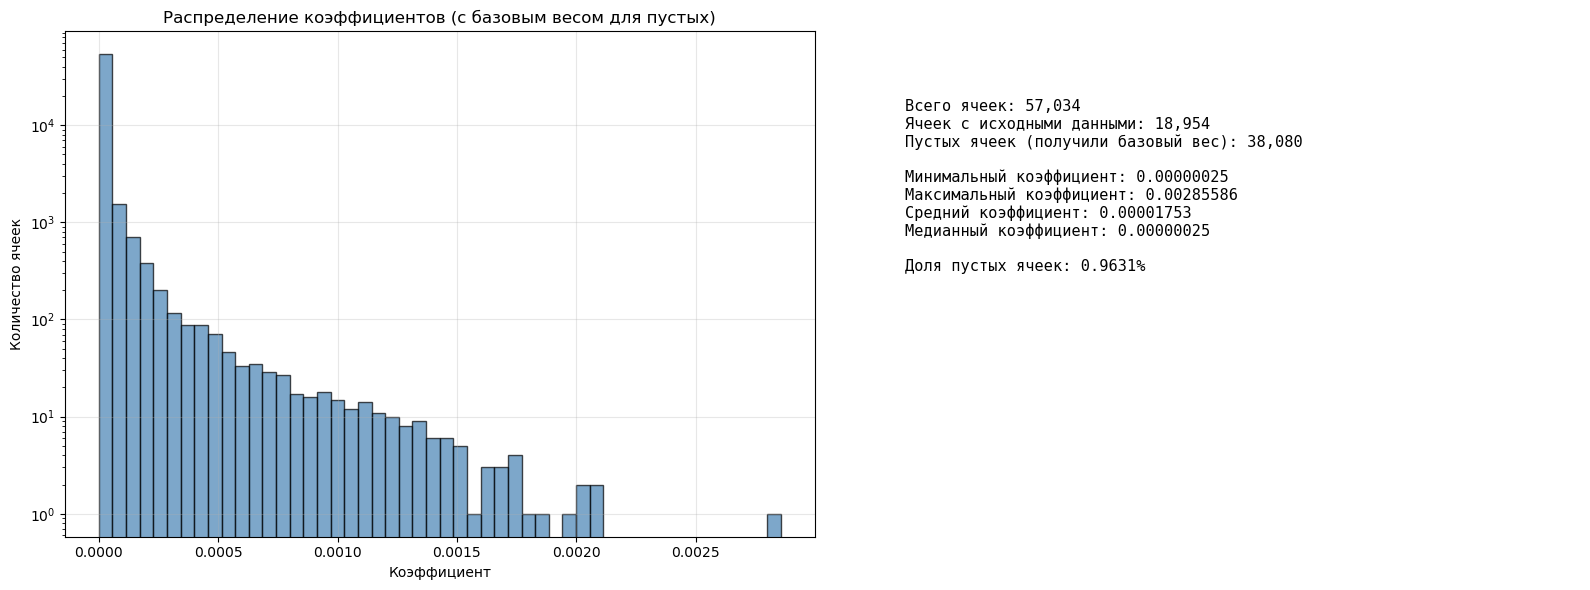

  Добавлена колонка: coefficient_freq
  Сумма коэффициентов: 1.00


In [15]:
# Визуализация распределения коэффициентов
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
all_coeffs = df_main["coefficient_freq"]
ax1.hist(all_coeffs, bins=50, edgecolor="black", alpha=0.7, color="steelblue")
ax1.set_xlabel("Коэффициент")
ax1.set_ylabel("Количество ячеек")
ax1.set_title("Распределение коэффициентов (с базовым весом для пустых)")
ax1.set_yscale("log")
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.axis("off")
stats_text = f"""
Всего ячеек: {len(df_main):,}
Ячеек с исходными данными: {(df_main['cell_weight'] > 0).sum():,}
Пустых ячеек (получили базовый вес): {mask_empty.sum():,}

Минимальный коэффициент: {all_coeffs.min():.8f}
Максимальный коэффициент: {all_coeffs.max():.8f}
Средний коэффициент: {all_coeffs.mean():.8f}
Медианный коэффициент: {all_coeffs.median():.8f}

Доля пустых ячеек: {empty_share:.4%}
"""
ax2.text(
    0.1,
    0.9,
    stats_text,
    transform=ax2.transAxes,
    fontsize=11,
    verticalalignment="top",
    fontfamily="monospace",
)

plt.tight_layout()
plt.show()

# Добавление в основную таблицу
df_main["coefficient_freq"] = (
    df_main["cell_id"]
    .map(dict(zip(df_main["cell_id"], df_main["coefficient_freq"])))
    .fillna(0)
)

print(f"  Добавлена колонка: coefficient_freq")
print(f"  Сумма коэффициентов: {df_main['coefficient_freq'].sum():.2f}")

### <font color="green">Расчёт пространственных весов (влияние соседей)</font> 

In [16]:
def calculate_spatial_weights(df, weight_col, radius_km=2):
    """
    Для каждой ячейки усредняет веса всех соседей в радиусе (включая себя)
    """
    coords = df[["center_lon", "center_lat"]].values
    weights = df[weight_col].values

    radius_deg = radius_km / 111.0
    tree = cKDTree(coords)

    spatial_weights = []

    for i in range(len(df)):
        indices = tree.query_ball_point(coords[i], r=radius_deg)
        # Усредняем, а не суммируем
        total = np.mean([weights[j] for j in indices])
        spatial_weights.append(total)

    spatial_weights = np.array(spatial_weights)
    coefficient_spatial = spatial_weights / spatial_weights.sum()

    return coefficient_spatial


print("Расчет пространственных весов")

spatial_weights = calculate_spatial_weights(df_main, weight_col="coefficient_freq")

df_main["coefficient_spatial"] = spatial_weights

print(f"\nСтатистика пространственных весов:")
print(f"Средний вес: {df_main['coefficient_spatial'].mean():.6f}")
print(f"Максимальный вес: {df_main['coefficient_spatial'].max():.6f}")
print(f"Сумма коэффициентов: {df_main['coefficient_spatial'].sum():.6f}")

df_main["coefficient_spatial"] = (
    df_main["cell_id"]
    .map(dict(zip(df_main["cell_id"], df_main["coefficient_spatial"])))
    .fillna(0)
)

Расчет пространственных весов

Статистика пространственных весов:
Средний вес: 0.000018
Максимальный вес: 0.001763
Сумма коэффициентов: 1.000000


### <font color="green">Карта частотного распределения (без учета соседних ячеек)</font>

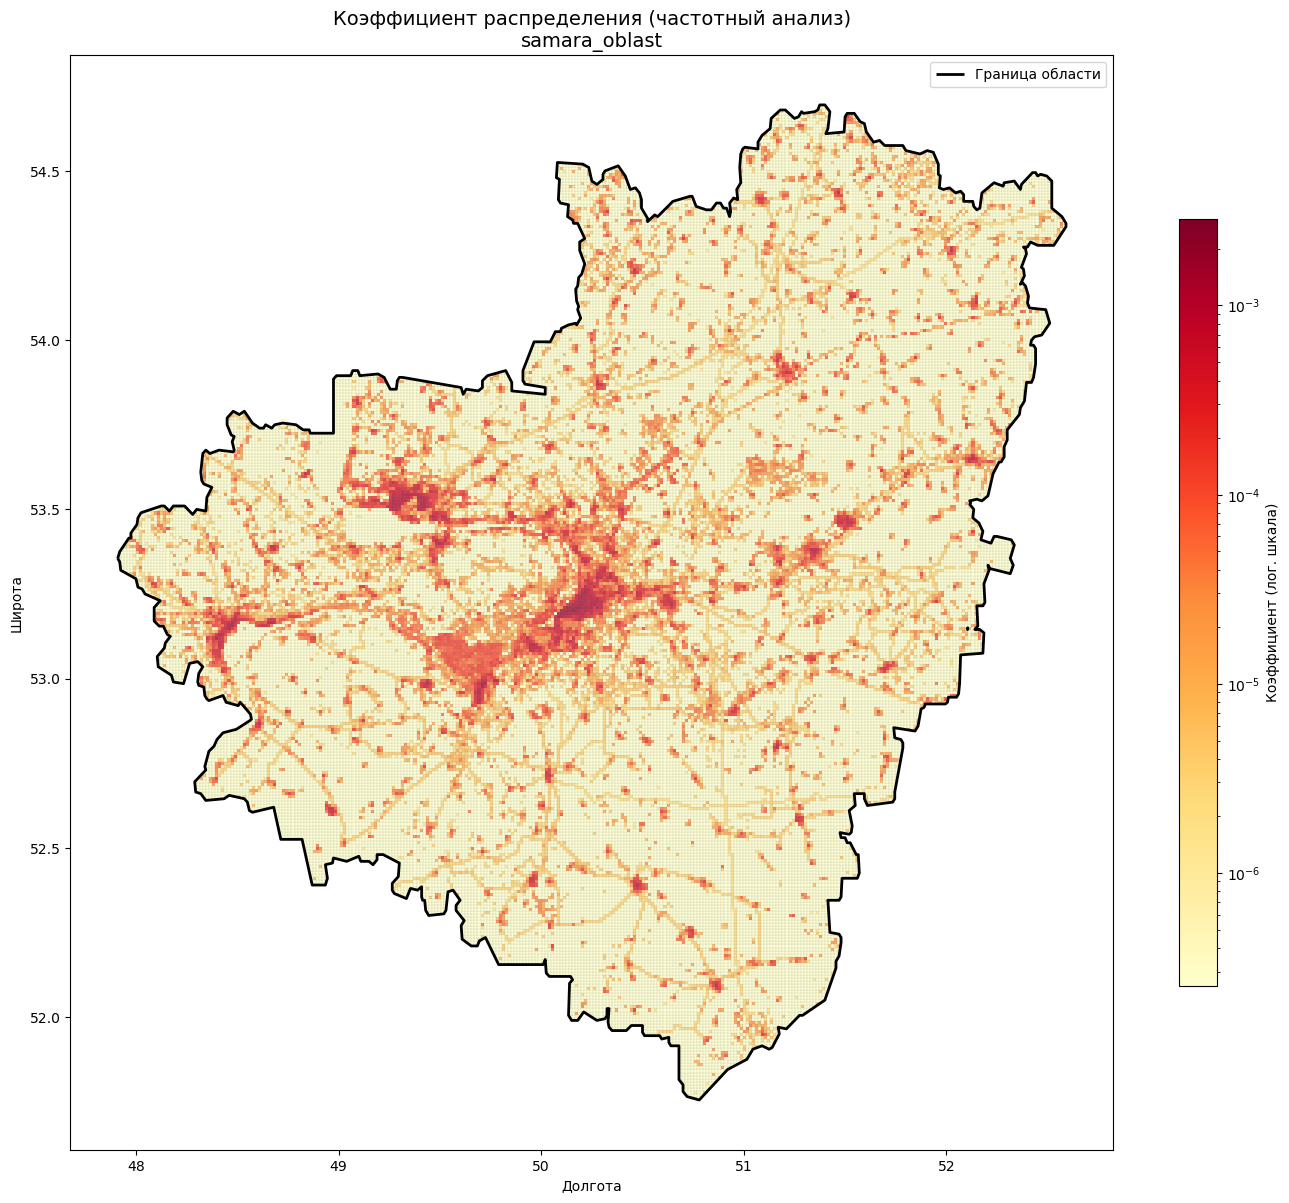

✅ Сохранено: result/samara_oblast.png


In [17]:
gdf_freq_coeff = grid_gdf.copy()
gdf_freq_coeff["coefficient_freq"] = (
    gdf_freq_coeff["cell_id"]
    .map(dict(zip(df_main["cell_id"], df_main["coefficient_freq"])))
    .fillna(0)
)

fig, ax = plt.subplots(1, 1, figsize=(14, 12))

gdf_freq_coeff.plot(
    column="coefficient_freq",
    ax=ax,
    cmap="YlOrRd",
    edgecolor="gray",
    linewidth=0.1,
    legend=True,
    norm=LogNorm(),
    alpha=0.8,
    legend_kwds={"label": "Коэффициент (лог. шкала)", "shrink": 0.7},
)

boundary.boundary.plot(ax=ax, color="black", linewidth=2, label="Граница области")
ax.set_title(f"Коэффициент распределения (частотный анализ)\n{name}", fontsize=14)
ax.set_xlabel("Долгота")
ax.set_ylabel("Широта")
ax.legend()

plt.tight_layout()
plt.savefig(f"result/{name}.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"✅ Сохранено: result/{name}.png")

### <font color="green">Карта частотного распределения (с учетом соседних ячеек)</font>

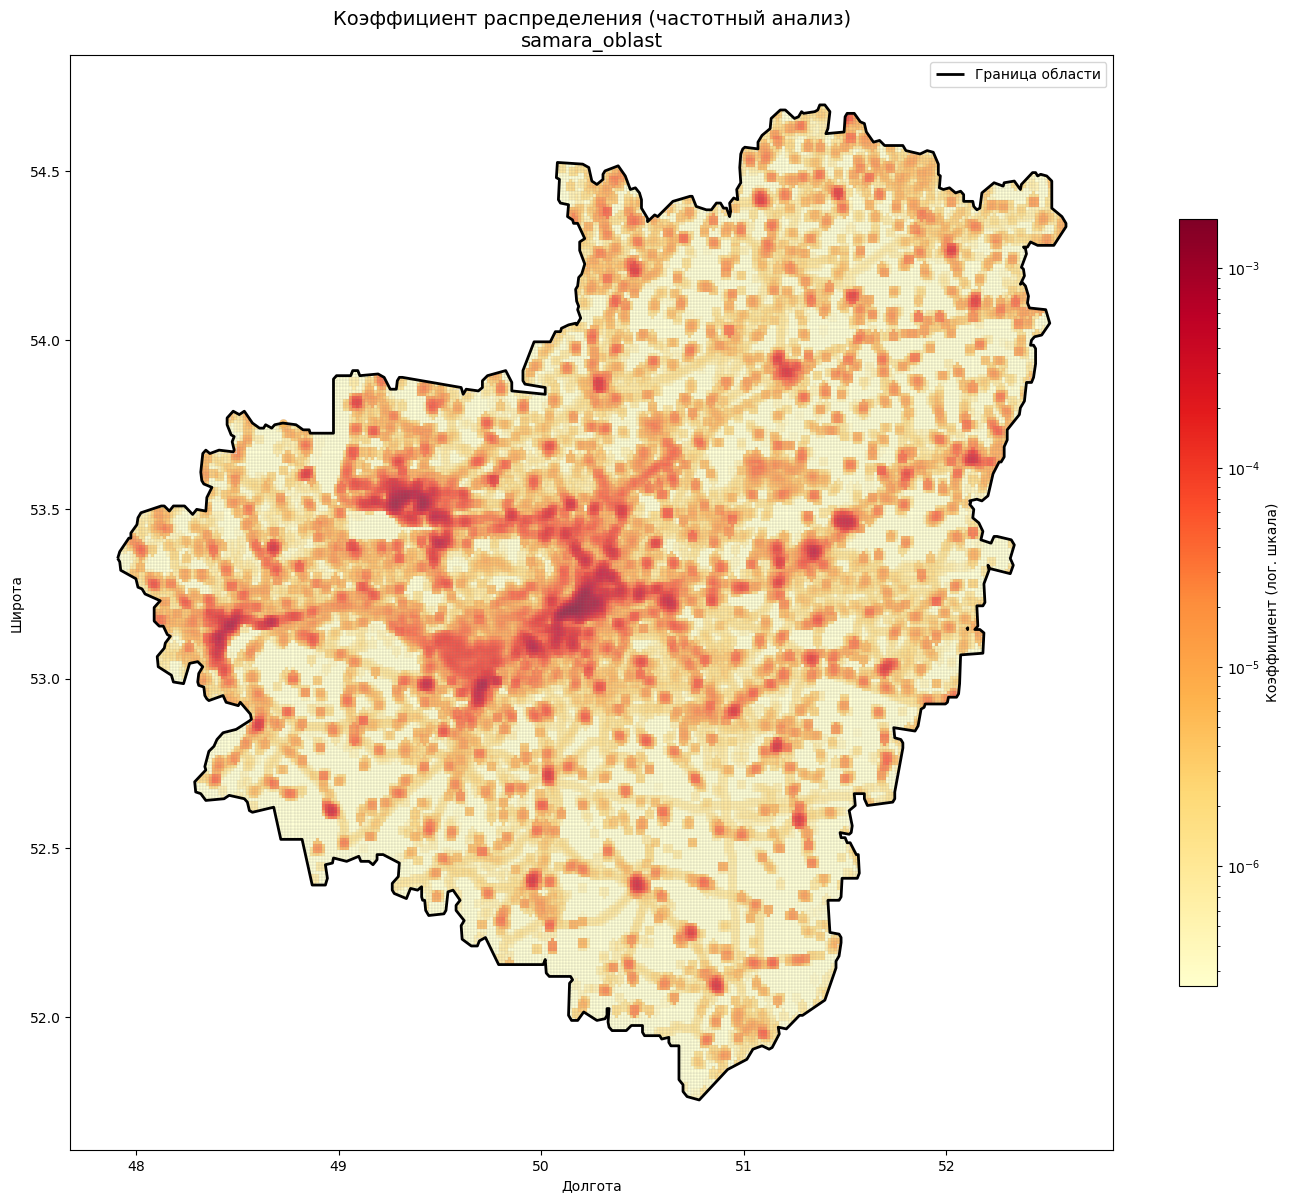

✅ Сохранено: result/samara_oblast_avg.png


In [18]:
gdf_freq_coeff = grid_gdf.copy()
gdf_freq_coeff["coefficient_spatial"] = (
    gdf_freq_coeff["cell_id"]
    .map(dict(zip(df_main["cell_id"], df_main["coefficient_spatial"])))
    .fillna(0)
)

fig, ax = plt.subplots(1, 1, figsize=(14, 12))

gdf_freq_coeff.plot(
    column="coefficient_spatial",
    ax=ax,
    cmap="YlOrRd",
    edgecolor="gray",
    linewidth=0.1,
    legend=True,
    norm=LogNorm(),
    alpha=0.8,
    legend_kwds={"label": "Коэффициент (лог. шкала)", "shrink": 0.7},
)

boundary.boundary.plot(ax=ax, color="black", linewidth=2, label="Граница области")
ax.set_title(f"Коэффициент распределения (частотный анализ)\n{name}", fontsize=14)
ax.set_xlabel("Долгота")
ax.set_ylabel("Широта")
ax.legend()

plt.tight_layout()
plt.savefig(f"result/{name}_avg.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"✅ Сохранено: result/{name}_avg.png")

### <font color="green">Сохранение данных</font>

In [19]:
df_main[
    [
        "cell_id",
        "cell_x",
        "cell_y",
        "types_json",
        "center_lon",
        "center_lat",
        "coefficient_freq",
        "coefficient_spatial",
    ]
].to_csv(f"result/{name}.csv", index=False, encoding="utf-8")

### <font color="green">Пример использования (расчет показателя)</font>

Ниже представлен код, демонстрирующий, как распределить показатель между ячейками 1×1 км на основе коэффициента `coefficient_freq`.

```python
regional_ratio = 10_000_000
df_main["allocated_ratio"] = regional_ratio * df_main["coefficient_freq"]

print("Распределение показателя")
print(f"Показатель: {regional_ratio:,.0f} руб.")
print(f"Сумма распределения: {df_main['allocated_ratio'].sum():,.0f} руб.")